INFO:numexpr.utils:NumExpr defaulting to 12 threads.
/opt/conda/envs/km310gpu/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


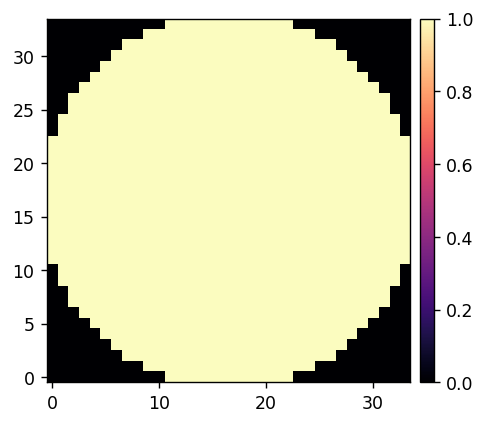

In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.patches import Circle, Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.animation import FFMpegWriter, PillowWriter
plt.rcParams['animation.html'] = 'html5'

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import iefc, dm, utils, rt_utils, coro_utils

Nact = 34
ncamsci = 256
camsci_pxscl_lamDc = 0.301

dm_mask = dm.create_mask(Nact=34)
utils.imshow([dm_mask])

In [2]:
data_dir = Path('../data/20260410')

calib_data_fpath = data_dir/'calib_data.pkl'
results_data_fpath = data_dir/'iefc_results_90.pkl'


In [3]:
calib_data = utils.load_pickle(calib_data_fpath)
xshift = calib_data['xshift']
yshift = calib_data['yshift']
xshift_lamD = xshift * camsci_pxscl_lamDc
yshift_lamD = yshift * camsci_pxscl_lamDc

In [4]:
iefc_data = utils.load_pickle(results_data_fpath)

raw_ims = ensure_np_array(xp.array(iefc_data['raw_images']))
ni_images = ensure_np_array(xp.array(iefc_data['ni_images']))
contrasts = ensure_np_array(xp.array(iefc_data['contrasts']))
commands = ensure_np_array(xp.array(iefc_data['commands']))
del_commands = ensure_np_array(xp.array(iefc_data['del_commands']))

contrasts = np.insert(contrasts, 0, 1.3e-6, )
Nitr = len(contrasts)

1076


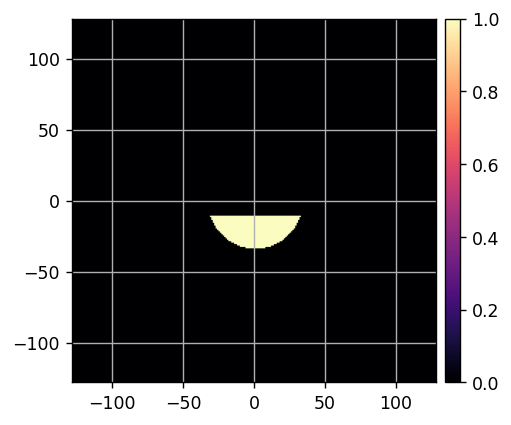

In [5]:
ncamsci = 256
iwa = 3
owa = 10
rotation = 90
dh_mask = utils.create_annular_mask(
    ncamsci, 
    camsci_pxscl_lamDc,
    iwa, 
    owa, 
    edge=iwa, 
    x_shift=calib_data['xshift'],
    y_shift=calib_data['yshift'],
    rotation=rotation,
    return_np=1,
)
print(dh_mask.sum())
utils.imshow(
    [dh_mask],
    pxscls=[1],
    grids=[1,]
)


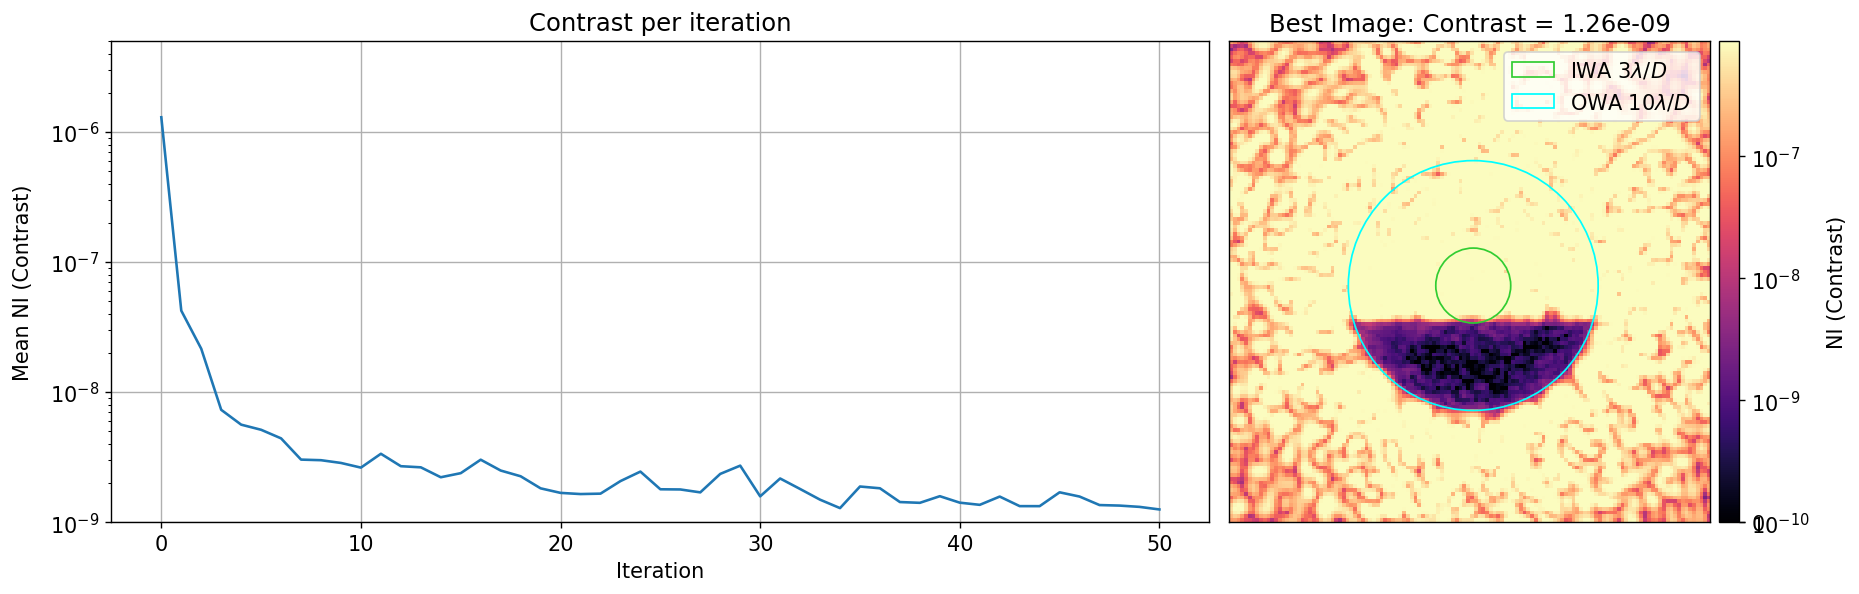

In [6]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(17,5), dpi=125, gridspec_kw={'width_ratios':[2,1]})

axs[0].semilogy(range(Nitr),contrasts)
axs[0].set_xlabel('Iteration', fontsize=12)
axs[0].set_ylabel('Mean NI (Contrast)', fontsize=12, labelpad=10)
axs[0].set_title('Contrast per iteration', fontsize=14)
axs[0].set_ylim(1e-9, 5e-6)
# axs[0].set_xticklabels( labelsize=10)
axs[0].grid()
axs[0].tick_params(axis='both', labelsize=12)

nim = 128
ni_im = utils.pad_or_crop(ni_images[-1], nim)
ext = nim/2 * camsci_pxscl_lamDc

im = axs[1].imshow(ni_im, extent=[-ext, ext, -ext, ext], norm=SymLogNorm(1e-10, 1e-7), cmap='magma')
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="4%", pad=0.075)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel('NI (Contrast)', rotation=90, labelpad=10, fontsize=12)
cbar.ax.tick_params(labelsize=12)

axs[1].set_title(f'Best Image: Contrast = {contrasts[-1]:.2e}', fontsize=14)
axs[1].set_xticks([])
axs[1].set_yticks([])

axs[1].add_patch(Circle((xshift_lamD,yshift_lamD), iwa, fill=False, color='limegreen', label=f'IWA {iwa}$\lambda/D$'))
axs[1].add_patch(Circle((xshift_lamD,yshift_lamD), owa, fill=False, color='cyan', label=f'OWA {owa}$\lambda/D$'))
axs[1].legend(fontsize=12)

plt.subplots_adjust(
    wspace=0.0,
)

In [57]:
def create_time_series_anim(
        del_commands, 
        commands, 
        ni_ims,
        contrasts,
        interval=0.2, # in s
    ):
    numframes = ni_ims.shape[0]
    print(numframes)
    
    i = 0

    fig, axs = plt.subplots(
        nrows=1, ncols=3, 
        figsize=(16,5), 
        dpi=125, 
    )

    ax = axs[0]
    im1 = ax.imshow(del_commands[i], cmap='viridis', )
    im1_title = ax.set_title(f'$\Delta$ Command {i+1}')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im1, cax=cax, format='%.1f')
    cbar.ax.set_ylabel('Displacement [nm]', rotation=90, labelpad=10)

    ax = axs[1]
    im2 = ax.imshow(commands[i], cmap='viridis', )
    im2_title = ax.set_title(f'Total Command {i+1}')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im2, cax=cax, format='%.1f')
    cbar.ax.set_ylabel('Displacement [nm]', rotation=90, labelpad=10)

    ax = axs[2]
    nim = 128
    ni_im = utils.pad_or_crop(ni_images[i], nim)
    ext = nim/2 * camsci_pxscl_lamDc
    extent = [-ext, ext, -ext, ext]
    im3 = ax.imshow(ni_im, norm=SymLogNorm(1e-10), cmap='magma', extent=extent)
    im3_title = ax.set_title(f'NI Image: Contrast = {contrasts[i+1]:.2e} ')
    ax.set_xticks([])
    ax.set_yticks([])
    # ax.set_xlabel('X [$\lambda/D$]')
    # ax.set_ylabel('Y [$\lambda/D$]')
    axs[2].add_patch(Circle((xshift_lamD,yshift_lamD), iwa, fill=False, color='limegreen', label=f'IWA {iwa}$\lambda/D$'))
    axs[2].add_patch(Circle((xshift_lamD,yshift_lamD), owa, fill=False, color='cyan', label=f'OWA {owa}$\lambda/D$'))
    axs[2].legend(fontsize=12)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im3, cax=cax, )
    cbar.ax.set_ylabel('Mean NI', rotation=90, labelpad=5)

    def animate(i):
        im1.set_data(del_commands[i])
        im1_title.set_text(f'$\Delta$ Command {i+1}')
        im1.set_clim([np.min(del_commands[i]), np.max(del_commands[i])])

        im2.set_data(commands[i])
        im2_title.set_text(f'Total Command {i+1}')
        im2.set_clim([np.min(commands[i]), np.max(commands[i])])

        ni_im = utils.pad_or_crop(ni_images[i], nim)
        im3.set_data(ni_im)
        im3_title.set_text(f'NI Image: Contrast = {contrasts[i+1]:.2e} ')
        im3.set_clim([1e-10, np.max(ni_im)])
        
    fig.subplots_adjust(
        left=0.05,
        right=0.95,
        wspace=0.35,
    )
    anim = matplotlib.animation.FuncAnimation(fig, animate, frames=numframes, interval=interval*1000)
    return anim

50


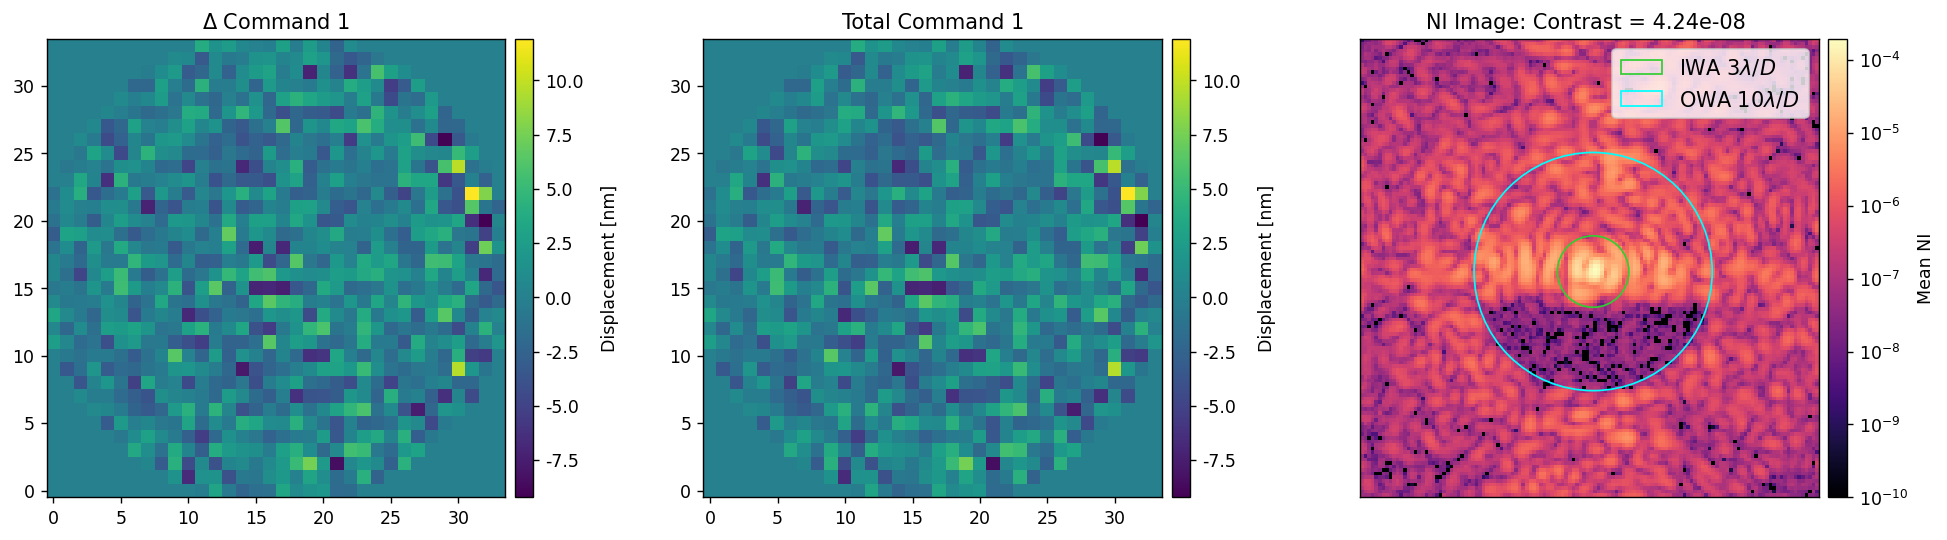

In [58]:
anim = create_time_series_anim(
    del_commands*1e9, 
    commands*1e9, 
    ni_images,
    contrasts,
    interval=0.5, # in s
    )

In [59]:
anim

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:figure size in inches has been adjusted from 16.0 x 5.0 to 16.0 x 4.992
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 2000x624 -pix_fmt rgba -framerate 2.0 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /tmp/tmpcwr5h44y/temp.m4v
